In [2]:
#Import libraries
import pandas as pd
from affine import Affine
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import folium
import math
import time
import sys
import geopy
import numpy as np
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster, PolyLineTextPath
from shapely.geometry import MultiPolygon
from shapely.ops import split, unary_union
from statistics import mean,median
from pykrige.ok import OrdinaryKriging
from matplotlib import cm, colors
from io import BytesIO
import base64
from PIL import Image
from rasterio.features import rasterize
from affine import Affine
import rasterio
from rasterio import features
from shapely.geometry import mapping

print("Import complete")

Import complete


In [2]:
### IMPORT DATA AND MERGE DATA

#tec_data=pd.read_csv("tec_data.csv")
#rot_data=pd.read_csv("rotations.csv")

#TEMPORARY
rot_data=pd.read_csv(r"C:\Users\rosso\Documents\PMAGpython\results\results.csv")
tec_data=pd.read_csv(r"C:\Users\rosso\Documents\PMAGpython\temp_tec.csv")
###

rot_data["name"] = tec_data["name"].values

merged= pd.merge(tec_data, rot_data, on="name", suffixes=("_tec", "_rot"))

overlap_cols = set(tec_data.columns) & set(rot_data.columns)
overlap_cols.discard("name")  # Don't process the key column

print(merged.head)
print(overlap_cols)

for col in overlap_cols:
    merged[col] = merged[f"{col}_tec"].combine_first(merged[f"{col}_rot"])
    merged.drop([f"{col}_tec", f"{col}_rot"], axis=1, inplace=True)


###NOTE THESE COLUMNS ARE ONLY FOR MY COMPILATION FORMAT. Be advised, this needs to be changed if we admit another format.
merged_data=merged[["Island","name","N","age","min_age","max_age", "mdec","minc","a95","k","R","delta_R","R_sig","A95","B95","K",
             "plat","plon","lambda","L","delta_L", "L_sig",
             "ref_dec","ref_inc","ref_mean_N","ref_mean_K","period","slat","slon","Ref","Notes"]]


###ATTRIBUTE ROTATION SENSE TO THE DATA
def rot_sense(df):
    df["rot_sense"]=""
    for idx, row in df.iterrows():
        if row["R_sig"] and row["R"] > 0:
            df.loc[idx, "rot_sense"] = "CW"
        elif row["R_sig"] and row["R"]<0:
            df.loc[idx, "rot_sense"] = "CCW"
        else:
            df.loc[idx, "rot_sense"] = ""
    return df

data=rot_sense(merged_data)

#(OPTIONAL) Inspect and/or export data
#data.to_csv("data.csv", index=False)
data

KeyError: 'name'

Index(['R', 'delta_R', 'R_sig', 'L', 'delta_L', 'L_sig', 'B95', 'ref_dec',
       'ref_inc', 'ref_mean_N', 'ref_mean_K', 'MaxAgeMag', 'MinAgeMag', 'mdec',
       'minc', 'a95', 'k', 'Ref', 'K', 'Notes', 'Polarity', 'period', 'lambda',
       'N', 'slon', 'plon', 'A95', 'age', 'min_age', 'plat', 'max_age',
       'slat'],
      dtype='object')


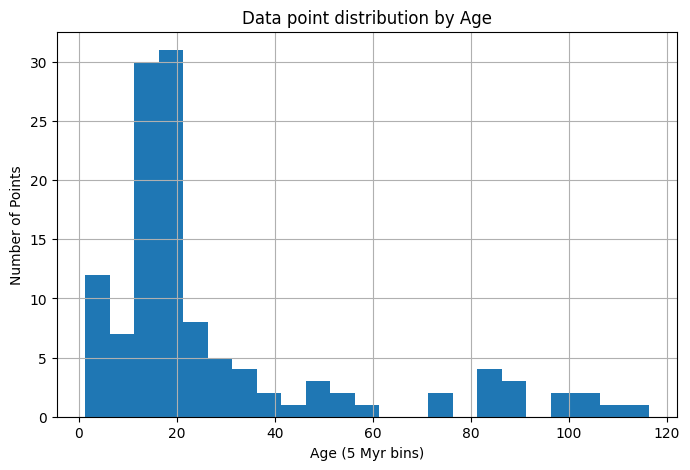

In [3]:
#TEMPORARY STRUCTURE  JUST TO MAKE SURE THE WHOLE PIPELINE WORKS

rot_data=pd.read_csv(r"C:\Users\rosso\Documents\PMAGpython\results\results.csv")
tec_data=pd.read_csv(r"C:\Users\rosso\Documents\PMAGpython\temp_tec.csv")

tec_data_renamed = tec_data.add_suffix("_tec")
rot_data_renamed = rot_data.add_suffix("_rot")

merged = pd.concat([rot_data_renamed, tec_data_renamed], axis=1)

overlap_cols = set(tec_data.columns) & set(rot_data.columns)
overlap_cols.discard("name")

for col in overlap_cols:
    merged[col] = merged[f"{col}_tec"].combine_first(merged[f"{col}_rot"])
    merged.drop([f"{col}_tec", f"{col}_rot"], axis=1, inplace=True)

#merged_data=merged[["Island","name","N","age","min_age","max_age", "mdec","minc","a95","k","R","delta_R","R_sig","A95","B95","K",
#             "plat","plon","lambda","L","delta_L", "L_sig",
#             "ref_dec","ref_inc","ref_mean_N","ref_mean_K","period","slat","slon","Ref","Notes"]]
merged.columns = merged.columns.str.replace(r'(_rot|_tec)$', '', regex=True)
print(merged.columns)

def rot_sense(df):
    df["rot_sense"]=""
    for idx, row in df.iterrows():
        if row["R_sig"] and row["R"] > 0:
            df.loc[idx, "rot_sense"] = "CW"
        elif row["R_sig"] and row["R"]<0:
            df.loc[idx, "rot_sense"] = "CCW"
        else:
            df.loc[idx, "rot_sense"] = ""
    return df

data=rot_sense(merged)

bins = np.arange(data["age"].min(), data["age"].max() + 5, 5)

plt.figure(figsize=(8,5))
plt.hist(data["age"], bins=bins)

plt.xlabel("Age (5 Myr bins)")
plt.ylabel("Number of Points")
plt.title("Data point distribution by Age")
plt.grid(True)

plt.show()

In [4]:
filtered_data = data[(data["age"] >= 18) & (data["age"] <= 60)]

print(len(filtered_data))

rads = np.deg2rad(filtered_data['R'].values)

filtered_data['cos'] = np.cos(rads)
filtered_data['sin'] = np.sin(rads)

X = filtered_data['slon'].values
Y = filtered_data['slat'].values
Zx = filtered_data['cos'].values
Zy = filtered_data['sin'].values

min_lat, max_lat = filtered_data['slat'].min(), filtered_data['slat'].max()
min_lon, max_lon = filtered_data['slon'].min(), filtered_data['slon'].max()
grid_lon = np.linspace(min_lon, max_lon, 1000)
grid_lat = np.linspace(min_lat, max_lat, 1000)

ok_x = OrdinaryKriging(X, Y, Zx,
                       variogram_model='spherical', verbose=False, enable_plotting=False)
zx_pred, zx_ss = ok_x.execute('grid', grid_lon, grid_lat)

ok_y = OrdinaryKriging(X, Y, Zy,
                       variogram_model='spherical', verbose=False, enable_plotting=False)
zy_pred, zy_ss = ok_y.execute('grid', grid_lon, grid_lat)

# zx_pred and zy_pred are 2D arrays on the grid
# Normalize vector length to avoid numerical issues
magnitude = np.sqrt(zx_pred**2 + zy_pred**2)
# avoid divide by zero
magnitude[magnitude == 0] = 1.0
nx = zx_pred / magnitude
ny = zy_pred / magnitude

# Convert back to angles (radians -> degrees, range -180..180)
theta_rad = np.arctan2(ny, nx)
theta_deg = np.rad2deg(theta_rad)

# Optionally convert to 0..360
theta_deg360 = (theta_deg + 360) % 360

print(theta_deg360.shape)



33


C:\Users\rosso\AppData\Local\Temp\ipykernel_24104\402139067.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['cos'] = np.cos(rads)
C:\Users\rosso\AppData\Local\Temp\ipykernel_24104\402139067.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['sin'] = np.sin(rads)


(1000, 1000)


In [6]:
### PLOTTER APP
#Step 1 -- make DataFrame into a GeoDataFrame and load shape files
def create_geodataframe(df: pd.DataFrame) -> gpd.GeoDataFrame:
    geometry = gpd.points_from_xy(df['slon'], df['slat'])
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    return gdf

gdf = create_geodataframe(data)

### SHAPE FILES -- NOTE use diferent files (GPlates?)
#perfectures_path = gpd.read_file(r"C:\Users\bruno\Desktop\japan\Script\japan-prefecture-boundaries\japan-prefecture-boundaries.shp")
#perfectures = gpd.GeoDataFrame(perfectures_path, crs="EPSG:4326")


#Step 2 -- Plotter App!
#NOTE --> If there is another type of plot you'd like to use instead, please let me know!
def plot():
    val = input()
    m = folium.Map(location=[38.5,138.2529], tiles='cartodbpositron', zoom_start=5)
    if val == "1":
        for idx, row in gdf.iterrows():
            Marker([row["slat"],row["slon"]]).add_to(m)
        return m


    if val == "2":
        joined = gpd.sjoin(gdf, perfectures, how="left", predicate="within")
        summary = joined.groupby('prefecture').agg(site_count=('mdec', 'count')).reset_index()
        perfectures_summary = perfectures.merge(summary, on='prefecture', how='left')
        folium.Choropleth(
            geo_data=perfectures_summary,
            name='choropleth',
            data=perfectures_summary,
            columns=['prefecture', 'site_count'],
            key_on='feature.properties.prefecture',
            fill_color='YlOrRd',
            fill_opacity=0.7,
            line_opacity=0.2,
            nan_fill_color='white',
            nan_fill_opacity=0.5,
            legend_name='Number of Sites').add_to(m)
        def popup_html(row):
            return f"""
                <b>Prefecture:</b> {row['prefecture']}<br>
                <b>Site count:</b> {row['site_count'] if not pd.isna(row['site_count']) else 0}"""
        for _, row in perfectures_summary.iterrows():
            folium.GeoJson(row['geometry'],
                style_function=lambda x: {'fillColor': 'YlGnBu'}, 
                popup=folium.Popup(popup_html(row), 
                max_width=250)).add_to(m)
        m.save("map_prefecture_summary.html")
        return m
    

    if val == "3":
        
        def add_direction_arrow(map_obj, lat, lon, dec_deg, rot_sense, dec, inc, a95, k, ref, length=1):
            #Calculate the end point of the arrow based on declination
            angle_rad = np.deg2rad(dec_deg)
            dlat = length * np.cos(angle_rad)
            dlon = length * np.sin(angle_rad)
            end_lat = lat + dlat
            end_lon = lon + dlon
            if rot_sense=="CW":
                color="red"
            elif rot_sense=="CCW":
                color="blue"
            else:
                color="black"
            popup_html = f"""   <b>Dec:</b> {dec}<br>
                                <b>Inc:</b> {inc}<br>
                                <b>a95:</b> {a95}<br>
                                <b>k:</b> {k}<br>
                                <b>Lat:</b> {lat}<br>
                                <b>Lon:</b> {lon}<br>
                                <b>Reference:</b> {ref}"""
            line = folium.PolyLine(locations=[(lat, lon), (end_lat, end_lon)], 
                                   color='blue', 
                                   opacity=0,
                                   popup=folium.Popup(popup_html, max_width=300)).add_to(map_obj)
            folium.CircleMarker(location=(lat, lon),
                                radius=10,
                                color=color,
                                fill=True,
                                fill_opacity=0,
                                opacity=0,
                                popup=folium.Popup(popup_html, max_width=300)
            ).add_to(map_obj)
            PolyLineTextPath(
                line,
                '➤',
                repeat=False,
                offset=1,
                attributes={'font-size': '20', 'fill': color}).add_to(map_obj)
        for idx, row in gdf.iterrows():
                add_direction_arrow(
                    m, row["slat"], row["slon"], row["mdec"], row["rot_sense"], 
                    row["mdec"], row["minc"], row["a95"], row["k"], row["Ref"])
        legend_html = """<div style='position: fixed; bottom: 50px; left: 50px; width: 180px; z-index:9999; font-size:14px;
                        background-color: white; border:2px solid grey; border-radius:8px; padding: 10px;'>
                        <b>Rotation Sense</b><br><i style='background:red;width:18px;height:18px;float:left;
                        margin-right:8px;opacity:0.8;display:inline-block;'></i>CW (Clockwise)<br>
                        <i style='background:blue;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;
                        display:inline-block;'></i>CCW (Counterclockwise)<br></div>"""

        m.get_root().html.add_child(folium.Element(legend_html)) 
        m.save("map_declination.html")
        return m
    

    if val == "4":

        period_color_map = {"Quaternary": "#FFFF00",     
            "Neogene": "#FFCC99",        
            "Paleogene": "#FF9900",      
            "Cretaceous": "#00FF00",     
            "Jurassic": "#339966",       
            "Triassic": "#FF0000",       
            "Permian": "#FF99CC",        
            "Carboniferous": "#006633",  
            "Devonian": "#66FFFF",       
            "Silurian": "#33CCFF",       
            "Ordovician": "#0066FF",     
            "Cambrian": "#0000FF",       
            "Precambrian": "#CCCCCC",    
            "Unknown": "#000000"}
        def period_to_hex(period):
            return period_color_map.get(period, "#000000")
    
        def add_direction_arrow(map_obj, lat, lon, dec_deg, period, age, age_error, dec, inc, ref, length=1):
            angle_rad = np.deg2rad(dec_deg)
            dlat = length * np.cos(angle_rad)
            dlon = length * np.sin(angle_rad)
            end_lat = lat + dlat
            end_lon = lon + dlon
            color = period_to_hex(period)
            popup_html = f"""   <b>Dec:</b> {dec}<br>
                                <b>Inc:</b> {inc}<br>
                                <b>Period:</b> {period}<br>
                                <b>Age:</b> {age} <b>±</b> {age_error}<br>
                                <b>Lat:</b> {lat}<br>
                                <b>Lon:</b> {lon}<br>
                                <b>Reference:</b> {ref}"""
            line = folium.PolyLine(locations=[(lat, lon), (end_lat, end_lon)],
                                   color='blue',
                                   opacity=0,
                                   popup=folium.Popup(popup_html, max_width=300)).add_to(map_obj)
            folium.CircleMarker(location=(lat, lon),
                                radius=10,
                                color=color,
                                fill=True,
                                fill_opacity=0,
                                opacity=0,
                                popup=folium.Popup(popup_html, max_width=300)).add_to(map_obj)
            PolyLineTextPath(
                line,
                '➤',
                repeat=False,
                offset=1,
                attributes={'font-size': '20', 'fill': color}).add_to(map_obj)
        for idx, row in gdf.iterrows():
            add_direction_arrow(m, row["slat"], row["slon"], row["mdec"], row["period"], row["age"], [row["max_age"]-row["age"]],
                    row["mdec"], row["minc"], row["Ref"])
        m.save("map_declination_age.html")
        used_periods = gdf['period'].unique()
        legend_html = """
        <div style='position: fixed; 
            bottom: 50px; left: 50px; width: 220px; z-index:9999; font-size:14px;
            background-color: white; border:2px solid grey; border-radius:8px; padding: 10px;'>
        <b>Geological Period</b><br>
        """
        for period in used_periods:
            color = period_color_map.get(period, "#000000")
            legend_html += f"<i style='background:{color};width:18px;height:18px;float:left; \
                                margin-right:8px;opacity:0.8;display:inline-block;'></i>{period}<br>"
        legend_html += "</div>"
        m.get_root().html.add_child(folium.Element(legend_html))
        return m


    if val == "5":
        temp_gdf=gdf.copy()
        for idx, row in temp_gdf.iterrows():
            if row["R_sig"]:
                continue
            else:
                temp_gdf.drop(idx, inplace=True)
        pos = temp_gdf[gdf['R'] > 0]
        neg = temp_gdf[gdf['R'] < 0]
        pos_data = pos[['slat', 'slon', 'R']].values.tolist()
        neg_data = neg[['slat', 'slon', 'R']].copy()
        neg_data['R'] = neg_data['R'].abs()
        neg_data = neg_data[['slat', 'slon', 'R']].values.tolist()
        for idx, row in temp_gdf.iterrows():
            if row["R"] > 0:
                HeatMap(
                    pos_data,
                    min_opacity=0.5,
                    max_opacity=1,
                    radius=10,
                    blur=5,
                    gradient={0: 'white', 1: 'red'}
                ).add_to(m)
            if row["R"] < 0:
                HeatMap(
                    neg_data,
                    min_opacity=0.5,
                    max_opacity=1,
                    radius=10,
                    blur=5,
                    gradient={0: 'white', 1: 'blue'}
                ).add_to(m)
        m.save("map_rotation_heatmap.html")
        return m


    if val == "6":
        temp_gdf=gdf.copy()
        for idx, row in temp_gdf.iterrows():
            if row["R_sig"]:
                continue
            else:
                temp_gdf.drop(idx, inplace=True)

        joined = gpd.sjoin(temp_gdf, perfectures, how="left", predicate="within")
        def rotation_classify(df):
            pos = (df['R'] > 0).sum()
            neg = (df['R'] < 0).sum()
            if pos > neg:
                return "Positive"
            elif neg > pos:
                return "Negative"
            elif pos == 0 and neg == 0:
                return "No Data"
            else:
                return "Neutral"
        summary = joined.groupby('prefecture').apply(rotation_classify).reset_index()
        summary.columns = ['prefecture', 'rot_sense']
        perfectures_summary = perfectures.merge(summary, on='prefecture', how='left')
        color_map = {
            "Positive": "red",
            "Negative": "blue",
            "Neutral": "purple",
            "No Data": "lightgrey"}

        def style_function(feature):
            sense = feature['properties'].get('rot_sense', 'No Data')
            return {
                'fillColor': color_map.get(sense, 'lightgrey'),
                'color': 'black',
                'weight': 1,
                'fillOpacity': 0.7}
        folium.GeoJson(
            perfectures_summary,
            style_function=style_function,
            tooltip=folium.GeoJsonTooltip(fields=['prefecture', 'rot_sense'])
        ).add_to(m)
        legend_html = """
            <div style='position: fixed; bottom: 50px; left: 50px; width: 180px; z-index:9999; font-size:14px;
            background-color: white; border:2px solid grey; border-radius:8px; padding: 10px;'>
            <b>Prefecture Rotation</b><br>
            <i style='background:red;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;display:inline-block;'></i>Positive<br>
            <i style='background:blue;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;display:inline-block;'></i>Negative<br>
            <i style='background:purple;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;display:inline-block;'></i>Neutral<br>
            <i style='background:lightgrey;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;display:inline-block;'></i>No Data<br>
            </div>
            """
        m.save("map_prefecture_rotation.html")

    if val == "7":
        def add_direction_arrow(map_obj, lat, lon, dec_deg, rot_sense, dec, inc, a95, k, ref, length=1):
            #Calculate the end point of the arrow based on declination
            angle_rad = np.deg2rad(dec_deg)
            dlat = length * np.cos(angle_rad)
            dlon = length * np.sin(angle_rad)
            end_lat = lat + dlat
            end_lon = lon + dlon
            if rot_sense=="CW":
                color="red"
            elif rot_sense=="CCW":
                color="blue"
            else:
                color="black"
            popup_html = f"""   <b>Dec:</b> {dec}<br>
                                <b>Inc:</b> {inc}<br>
                                <b>a95:</b> {a95}<br>
                                <b>k:</b> {k}<br>
                                <b>Lat:</b> {lat}<br>
                                <b>Lon:</b> {lon}<br>
                                <b>Reference:</b> {ref}"""
            line = folium.PolyLine(locations=[(lat, lon), (end_lat, end_lon)], 
                                   color='blue', 
                                   opacity=0,
                                   popup=folium.Popup(popup_html, max_width=300)).add_to(map_obj)
            folium.CircleMarker(location=(lat, lon),
                                radius=10,
                                color=color,
                                fill=True,
                                fill_opacity=0,
                                opacity=0,
                                popup=folium.Popup(popup_html, max_width=300)
            ).add_to(map_obj)
            PolyLineTextPath(
                line,
                '➤',
                repeat=False,
                offset=1,
                attributes={'font-size': '20', 'fill': color}).add_to(map_obj)
        for idx, row in gdf.iterrows():
                add_direction_arrow(
                    m, row["slat"], row["slon"], row["mdec"], row["rot_sense"], 
                    row["mdec"], row["minc"], row["a95"], row["k"], row["Ref"])
        legend_html = """<div style='position: fixed; bottom: 50px; left: 50px; width: 180px; z-index:9999; font-size:14px;
                        background-color: white; border:2px solid grey; border-radius:8px; padding: 10px;'>
                        <b>Rotation Sense</b><br><i style='background:red;width:18px;height:18px;float:left;
                        margin-right:8px;opacity:0.8;display:inline-block;'></i>CW (Clockwise)<br>
                        <i style='background:blue;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;
                        display:inline-block;'></i>CCW (Counterclockwise)<br></div>"""

        m.get_root().html.add_child(folium.Element(legend_html)) 
        m.save("map_declination.html")
        return m
    
    
    return m

In [7]:
print("Please select what data you want to plot:" \
          "\n1. Map of site locations" \
          "\n2. Data summary per perfecture" \
          "\n3. All declination data and kriged rotations" \
          "\n4. Declination data and age" \
          "\n5. Intensity of rotations" \
          "\n6. Rotations by Prefecture" )

plot()

Please select what data you want to plot:
1. Map of site locations
2. Data summary per perfecture
3. All declination data and kriged rotations
4. Declination data and age
5. Intensity of rotations
6. Rotations by Prefecture


C:\Users\rosso\AppData\Local\Temp\ipykernel_24104\2968363797.py:113: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("hsv")               # circular colormap for angles



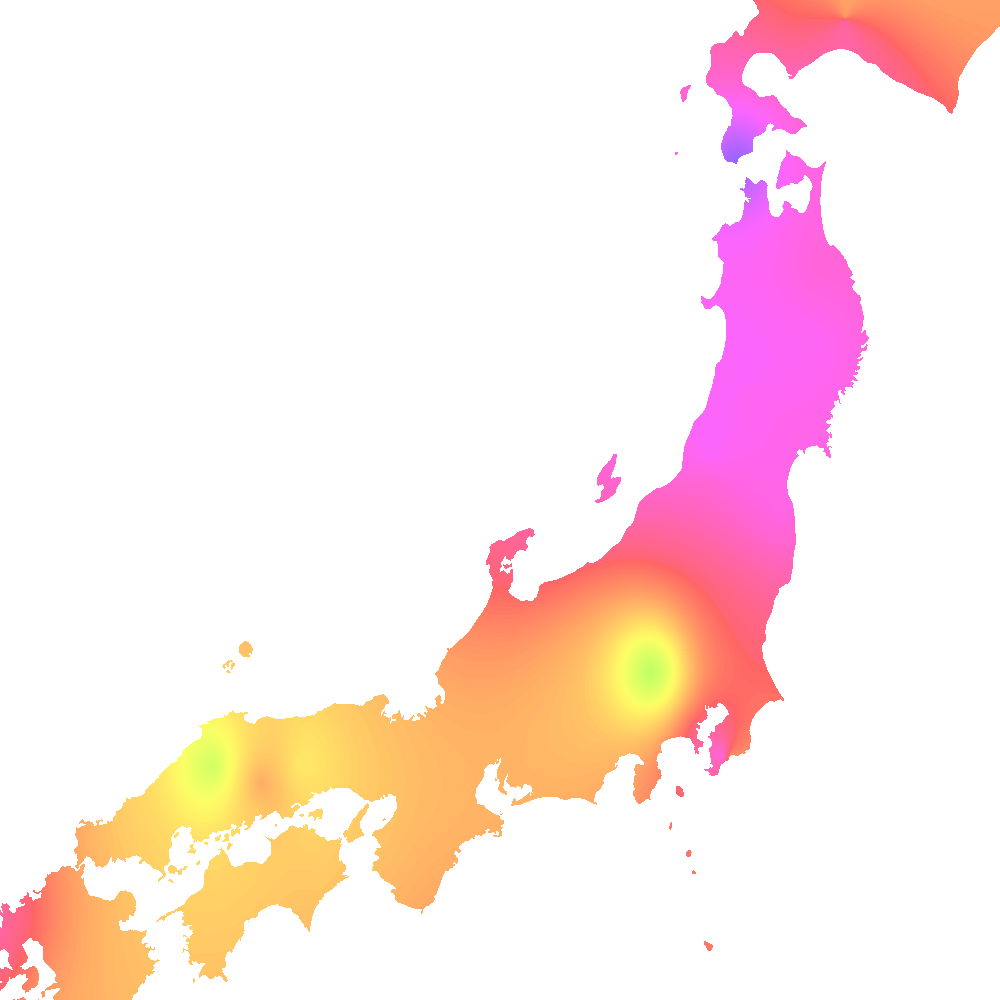

In [ ]:
world = gpd.read_file(r"C:\Users\rosso\Downloads\ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp")
country = world[world['NAME'] == "Japan"]

lats = np.linspace(min_lat, max_lat, 1000)   # n_lat = number of lat points in your cmap
lons = np.linspace(min_lon, max_lon, 1000)   # n_lon = number of lon points
lon_grid, lat_grid = np.meshgrid(lons, lats)

#mask = features.geometry_mask(
#   [mapping(country.geometry.values[0])],
#   transform=rasterio.transform.from_bounds(
#       west=lons.min(), south=lats.min(), east=lons.max(), north=lats.max(),
#       width=lon_grid.shape[1], height=lat_grid.shape[0]
#   ),
#   invert=True,
#   out_shape=lon_grid.shape
#)



mask = features.geometry_mask(
    geometries=[country.geometry.values[0]],
    out_shape=(len(lats), len(lons)),
    invert=True    # True = keep inside Japan
)

def create_geodataframe(df: pd.DataFrame) -> gpd.GeoDataFrame:
    geometry = gpd.points_from_xy(df['slon'], df['slat'])
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    return gdf

gdf = create_geodataframe(filtered_data)

m = folium.Map(location=[36,130], tiles='cartodbpositron', zoom_start=5)

def add_direction_arrow(map_obj, lat, lon, dec_deg, rot_sense, dec, inc, a95, k, ref, length=1):
            #Calculate the end point of the arrow based on declination

            half = length / 2

            angle_rad = np.deg2rad(dec_deg)
            dlat = half * np.cos(angle_rad)
            dlon = half * np.sin(angle_rad)

            start_lat = lat - dlat
            start_lon = lon - dlon
            
            end_lat = lat + dlat
            end_lon = lon + dlon
            if rot_sense=="CW":
                color="red"
            elif rot_sense=="CCW":
                color="blue"
            else:
                color="black"
            popup_html = f"""   <b>Dec:</b> {dec}<br>
                                <b>Inc:</b> {inc}<br>
                                <b>a95:</b> {a95}<br>
                                <b>k:</b> {k}<br>
                                <b>Lat:</b> {lat}<br>
                                <b>Lon:</b> {lon}<br>
                                <b>Reference:</b> {ref}"""
            line = folium.PolyLine(locations=[(start_lat, start_lon), (end_lat, end_lon)], 
                                   color='blue', 
                                   opacity=0,
                                   popup=folium.Popup(popup_html, max_width=300)).add_to(map_obj)
            folium.CircleMarker(location=(lat, lon),
                                radius=10,
                                color=color,
                                fill=True,
                                fill_opacity=0,
                                opacity=0,
                                popup=folium.Popup(popup_html, max_width=300)
            ).add_to(map_obj)
            PolyLineTextPath(
                line,
                '➤',
                repeat=False,
                offset=1,
                attributes={'font-size': '20', 'fill': color}).add_to(map_obj)
for idx, row in gdf.iterrows():
                add_direction_arrow(
                    m, row["slat"], row["slon"], row["mdec"], row["rot_sense"], 
                    row["mdec"], row["minc"], row["a95"], row["k"], row["Ref"])
legend_html = """<div style='position: fixed; bottom: 50px; left: 50px; width: 180px; z-index:9999; font-size:14px;
                        background-color: white; border:2px solid grey; border-radius:8px; padding: 10px;'>
                        <b>Rotation Sense</b><br><i style='background:red;width:18px;height:18px;float:left;
                        margin-right:8px;opacity:0.8;display:inline-block;'></i>CW (Clockwise)<br>
                        <i style='background:blue;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;
                        display:inline-block;'></i>CCW (Counterclockwise)<br></div>"""

m.get_root().html.add_child(folium.Element(legend_html)) 
m.save("map_declination.html")

dlon = grid_lon[1] - grid_lon[0]
dlat = grid_lat[1] - grid_lat[0]
lon_min = grid_lon.min()
lon_max = grid_lon.max()
lat_min = grid_lat.min()
lat_max = grid_lat.max()

def add_rotation_overlay_to_map(m, grid_lon, grid_lat, theta_deg360, alpha=0.6):
    cmap = cm.get_cmap("hsv")               # circular colormap for angles
    
    norm = colors.Normalize(vmin=0, vmax=360)
    rgba_img = np.flipud(cmap(norm(theta_deg360)))
    rgba_img[..., -1] = alpha
    rgba_img[~mask, -1] = 0

    img = Image.fromarray((rgba_img * 255).astype(np.uint8))
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    data_uri = "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("utf-8")

    # Add overlay
    overlay = folium.raster_layers.ImageOverlay(
        image=data_uri,
        bounds=[[lat_min, lon_min], [lat_max, lon_max],
        ],
        opacity=1.0,
        cross_origin=False,
        interactive=False
    )
    overlay.add_to(m)

    return m

add_rotation_overlay_to_map(m, grid_lon, grid_lat, theta_deg360, alpha=0.6)
m


